## latent umaps

In [1]:
import pathlib
import random
import sys

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from app_utils import generate_random_palette, load_model_data
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [6]:
cancer_type_input_file = pathlib.Path("../0.data-download/data/Model.parquet")
cancer_type_df = pd.read_parquet(cancer_type_input_file)

reactome_dims = pathlib.Path(
    "../5.drug-dependency/results/all_reactome_results.parquet"
)
reactome_df = pd.read_parquet(reactome_dims)

corum_dims = pathlib.Path("../5.drug-dependency/results/all_corum_results.parquet")
corum_df = pd.read_parquet(corum_dims)

drug_dims = pathlib.Path("../5.drug-dependency/results/all_drug_results.parquet")
drug_df = pd.read_parquet(drug_dims)
# Step 2: Subset based on matching keys
subset_keys = ["model", "latent_dim_total", "init", "z"]

# Replace latent identifiers with pathway
reactome_df["feature"] = reactome_df["reactome_pathway"]
reactome_df = reactome_df.drop(
    columns=["model", "latent_dim_total", "init", "seed", "z", "reactome_pathway"]
)

corum_df["feature"] = corum_df["reactome_pathway"]
corum_df = corum_df.drop(
    columns=["model", "latent_dim_total", "init", "seed", "z", "reactome_pathway"]
)

drug_df["feature"] = drug_df["name"]
drug_df = drug_df.drop(
    columns=["model", "latent_dim_total", "init", "seed", "z", "name"]
)
drug_df_sorted = drug_df.sort_values(
    by=["OncotreePrimaryDisease", "ModelID", "feature"], ascending=True
)
# Create a unique column name by combining feature and source
meta_cols = ["ModelID", "OncotreePrimaryDisease"]
reactome_meta = reactome_df[meta_cols].drop_duplicates()
corum_meta = corum_df[meta_cols].drop_duplicates()
drug_meta = drug_df[meta_cols].drop_duplicates()

# Pivot to wide format
reactome_matrix = reactome_df.pivot(
    index="ModelID", columns="feature", values="latent_score"
)
corum_matrix = corum_df.pivot(index="ModelID", columns="feature", values="latent_score")
drug_matrix = drug_df.pivot(index="ModelID", columns="feature", values="latent_score")

# Join metadata back to each matrix
reactome_matrix = reactome_matrix.merge(reactome_meta, on="ModelID", how="left")
corum_matrix = corum_matrix.merge(corum_meta, on="ModelID", how="left")
drug_matrix = drug_matrix.merge(drug_meta, on="ModelID", how="left")

In [7]:
import colorsys
import random


def generate_random_palette(num_colors, seed=12):
    # Generate random colors with varied lightness and saturation
    random.seed(seed)

    colors = []

    for _ in range(num_colors):
        h = random.random()  # Random hue between 0 and 1
        l = random.uniform(0.2, 0.8)  # Lightness between 0.3 and 0.9 for contrast
        s = random.uniform(0.5, 1.0)  # Saturation between 0.6 and 1.0 for vivid colors
        color = colorsys.hls_to_rgb(h, l, s)  # Convert HLS to RGB color
        colors.append(color)

    return colors

In [8]:
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Prepare PCA input (excluding non-numeric columns)
pca_input = combined_df[gene_cols].apply(pd.to_numeric, errors="coerce")
pca = PCA(n_components=2, random_state=0)
pca_embedding = pca.fit_transform(pca_input)

# Add PCA components to the dataframe
combined_df["PCA1"] = pca_embedding[:, 0]
combined_df["PCA2"] = pca_embedding[:, 1]

# Prepare color map for each cancer type
cancer_types = combined_df["OncotreePrimaryDisease"].unique()
color_map = (
    px.colors.qualitative.Plotly
    + px.colors.qualitative.Light24
    + px.colors.qualitative.Dark24
)
highlight_color_map = {
    cancer: color_map[i % len(color_map)] for i, cancer in enumerate(cancer_types)
}

# Create one trace per cancer type
traces = []
for cancer in cancer_types:
    df_subset = combined_df[combined_df["OncotreePrimaryDisease"] == cancer]
    trace = go.Scatter(
        x=df_subset["PCA1"],
        y=df_subset["PCA2"],
        mode="markers",
        name=cancer,
        marker=dict(size=7),
        text=[f"{cancer} | {model_id}" for model_id in df_subset["ModelID"]],
        hoverinfo="text",
    )
    traces.append(trace)

# Create dropdown buttons
dropdown_buttons = []

for i, cancer in enumerate(cancer_types):
    # Make all grey except the selected one
    visibility = [True] * len(cancer_types)
    colors = ["lightgrey"] * len(cancer_types)
    colors[i] = highlight_color_map[cancer]

    button = dict(
        method="update",
        label=cancer,
        args=[
            {
                "visible": visibility,
                "marker": [{"color": colors[j]} for j in range(len(cancer_types))],
            },
            {"title": f"PCA Highlighted: {cancer}"},
        ],
    )
    dropdown_buttons.append(button)

# Add a button to show all with normal colors
default_colors = [highlight_color_map[cancer] for cancer in cancer_types]
dropdown_buttons.insert(
    0,
    dict(
        method="update",
        label="Show All",
        args=[
            {
                "visible": [True] * len(cancer_types),
                "marker": [
                    {"color": default_colors[j]} for j in range(len(cancer_types))
                ],
            },
            {"title": "PCA of DepMap Single Gene Data"},
        ],
    ),
)

# Create the figure
fig = go.Figure(data=traces)

# Set default colors
for i, trace in enumerate(fig.data):
    trace.marker.color = default_colors[i]

fig.update_layout(
    title="PCA of DepMap Single Gene Data",
    xaxis_title="PCA1",
    yaxis_title="PCA2",
    updatemenus=[
        {
            "buttons": dropdown_buttons,
            "direction": "down",
            "showactive": True,
            "x": 1.15,
            "xanchor": "left",
            "y": 1.15,
            "yanchor": "top",
        }
    ],
    width=1500,
    height=800,
)

fig.show()
fig.write_html("achilles_pca.html")

NameError: name 'gene_cols' is not defined

## single-depedency-umaps

In [ ]:
import colorsys
import pathlib
import random

import ipywidgets as widgets
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go
from sklearn.decomposition import PCA

In [ ]:
cancer_type_input_file = pathlib.Path("../0.data-download/data/Model.parquet")
cancer_type_df = pd.read_parquet(cancer_type_input_file)

reactome_dims = pathlib.Path(
    "../5.drug-dependency/results/all_reactome_results.parquet"
)
reactome_df = pd.read_parquet(reactome_dims)

corum_dims = pathlib.Path("../5.drug-dependency/results/all_corum_results.parquet")
corum_df = pd.read_parquet(corum_dims)

drug_dims = pathlib.Path("../5.drug-dependency/results/all_drug_results.parquet")
drug_df = pd.read_parquet(drug_dims)

In [ ]:
reactome_df.head()

,ModelID,model,latent_dim_total,init,seed,OncotreePrimaryDisease,z,latent_score,reactome_pathway,nes_score,pathway_score
0,ACH-000001,betatcvae,16,4,1154917792,Ovarian Epithelial Tumor,1,0.306144,Formation Of Incision Complex In GG-NER R-HSA-...,3.247345,0.306144
1,ACH-000001,betatcvae,25,0,501796030,Ovarian Epithelial Tumor,1,0.657242,Citric Acid (TCA) Cycle And Respiratory Electr...,inf,0.657242
2,ACH-000001,betatcvae,90,0,1590696690,Ovarian Epithelial Tumor,1,0.455570,Polymerase Switching On C-strand Of Telomere R...,2.917680,0.455570
3,ACH-000001,betavae,5,3,4066919116,Ovarian Epithelial Tumor,1,0.000000,RHOC GTPase Cycle R-HSA-9013106,3.149455,0.000000
4,ACH-000001,betavae,10,2,1507182516,Ovarian Epithelial Tumor,1,0.159076,Nephrin Family Interactions R-HSA-373753,2.582687,0.159076


In [ ]:
# Step 2: Subset based on matching keys
subset_keys = ["model", "latent_dim_total", "init", "z"]

# Replace latent identifiers with pathway
reactome_df["feature"] = reactome_df["reactome_pathway"]
reactome_df = reactome_df.drop(
    columns=["model", "latent_dim_total", "init", "seed", "z", "reactome_pathway"]
)

corum_df["feature"] = corum_df["reactome_pathway"]
corum_df = corum_df.drop(
    columns=["model", "latent_dim_total", "init", "seed", "z", "reactome_pathway"]
)

drug_df["feature"] = drug_df["name"]
drug_df = drug_df.drop(
    columns=["model", "latent_dim_total", "init", "seed", "z", "name"]
)

In [ ]:
drug_df_sorted = drug_df.sort_values(
    by=["OncotreePrimaryDisease", "ModelID", "feature"], ascending=True
)
drug_df_sorted.head()

,ModelID,OncotreePrimaryDisease,latent_score,pearson_correlation,pathway_score,feature
597,ACH-000004,Acute Myeloid Leukemia,0.543216,-0.263962,0.543216,10-deacetylbaccatin
716,ACH-000004,Acute Myeloid Leukemia,0.740212,-0.252945,0.740212,"2,3-DCPE"
457,ACH-000004,Acute Myeloid Leukemia,0.832806,-0.275388,0.832806,3-deazaneplanocin-A
678,ACH-000004,Acute Myeloid Leukemia,0.641957,-0.320667,0.641957,9-aminoacridine
444,ACH-000004,Acute Myeloid Leukemia,0.546763,-0.262631,0.546763,ACY-1215


In [ ]:
# Create a unique column name by combining feature and source
meta_cols = ["ModelID", "OncotreePrimaryDisease"]
reactome_meta = reactome_df[meta_cols].drop_duplicates()
corum_meta = corum_df[meta_cols].drop_duplicates()
drug_meta = drug_df[meta_cols].drop_duplicates()

# Pivot to wide format
reactome_matrix = reactome_df.pivot(
    index="ModelID", columns="feature", values="latent_score"
)
corum_matrix = corum_df.pivot(index="ModelID", columns="feature", values="latent_score")
drug_matrix = drug_df.pivot(index="ModelID", columns="feature", values="latent_score")

# Join metadata back to each matrix
reactome_matrix = reactome_matrix.merge(reactome_meta, on="ModelID", how="left")
corum_matrix = corum_matrix.merge(corum_meta, on="ModelID", how="left")
drug_matrix = drug_matrix.merge(drug_meta, on="ModelID", how="left")

In [ ]:
def generate_random_palette(num_colors, seed=12):
    # Generate random colors with varied lightness and saturation
    random.seed(seed)

    colors = []

    for _ in range(num_colors):
        h = random.random()  # Random hue between 0 and 1
        l = random.uniform(0.2, 0.8)  # Lightness between 0.3 and 0.9 for contrast
        s = random.uniform(0.5, 1.0)  # Saturation between 0.6 and 1.0 for vivid colors
        color = colorsys.hls_to_rgb(h, l, s)  # Convert HLS to RGB color
        colors.append(color)

    return colors

In [ ]:
def make_dropdown_pca_with_selection(df, title="PCA Interactive Plot"):
    out = widgets.Output()  # Create a fresh output for this plot!

    # Prepare PCA input
    pca_input = df.drop(
        columns=["OncotreePrimaryDisease", "source", "ModelID"], errors="ignore"
    ).fillna(0)
    pca = PCA(n_components=2, random_state=0)
    embedding = pca.fit_transform(pca_input)

    # Add PCA coordinates to the dataframe
    df["PCA1"] = embedding[:, 0]
    df["PCA2"] = embedding[:, 1]

    # Prepare color map for each cancer type
    cancer_types = df["OncotreePrimaryDisease"].unique()
    color_map = (
        px.colors.qualitative.Plotly
        + px.colors.qualitative.Light24
        + px.colors.qualitative.Dark24
    )
    highlight_color_map = {
        cancer: color_map[i % len(color_map)] for i, cancer in enumerate(cancer_types)
    }

    # Create one trace per cancer type
    traces = []
    for cancer in cancer_types:
        df_subset = df[df["OncotreePrimaryDisease"] == cancer]
        trace = go.Scattergl(
            x=df_subset["PCA1"],
            y=df_subset["PCA2"],
            mode="markers",
            name=cancer,
            marker=dict(size=7, color=highlight_color_map[cancer]),
            text=[f"{cancer} | {model_id}" for model_id in df_subset["ModelID"]],
            customdata=df_subset["ModelID"],  # Attach ModelID to customdata
            hoverinfo="text",
        )
        traces.append(trace)

    # Dropdown buttons to highlight cancer types
    dropdown_buttons = []
    for i, cancer in enumerate(cancer_types):
        visibility = [True] * len(cancer_types)
        colors = ["lightgrey"] * len(cancer_types)
        colors[i] = highlight_color_map[cancer]

        button = dict(
            method="update",
            label=cancer,
            args=[
                {
                    "visible": visibility,
                    "marker": [{"color": colors[j]} for j in range(len(cancer_types))],
                },
                {"title": f"PCA Highlighted: {cancer}"},
            ],
        )
        dropdown_buttons.append(button)

    # Default color button
    default_colors = [highlight_color_map[cancer] for cancer in cancer_types]
    dropdown_buttons.insert(
        0,
        dict(
            method="update",
            label="Show All",
            args=[
                {
                    "visible": [True] * len(cancer_types),
                    "marker": [
                        {"color": default_colors[j]} for j in range(len(cancer_types))
                    ],
                },
                {"title": title},
            ],
        ),
    )

    fig = go.Figure(data=traces)

    for i, trace in enumerate(fig.data):
        trace.marker.color = default_colors[i]

    fig.update_layout(
        title=title,
        xaxis_title="PCA1",
        yaxis_title="PCA2",
        updatemenus=[
            {
                "buttons": dropdown_buttons,
                "direction": "down",
                "showactive": True,
                "x": 1.15,
                "xanchor": "left",
                "y": 1.15,
                "yanchor": "top",
            }
        ],
        dragmode="lasso",  # Ensure Lasso is enabled
        width=1500,
        height=800,
    )

    return fig, out  # Return both the figure and the output widget for selection

In [ ]:
# Assuming combined_df is your full dataset
reactome_fig, reactome_out = make_dropdown_pca_with_selection(
    reactome_matrix, "PCA: Reactome Subset"
)
corum_fig, corum_out = make_dropdown_pca_with_selection(
    corum_matrix, "PCA: CORUM Subset"
)
drug_fig, drug_out = make_dropdown_pca_with_selection(drug_matrix, "PCA: Drug Subset")

# Show plots
reactome_fig.show()
display(reactome_out)

corum_fig.show()
display(corum_out)

drug_fig.show()
display(drug_out)

# Save HTMLs
reactome_fig.write_html("pca_reactome.html")
corum_fig.write_html("pca_corum.html")
drug_fig.write_html("pca_drug.html")

Output()

Output()

Output()

## spider plots

In [9]:
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [32]:
model_ids = ["ACH-000323", "ACH-002083", "ACH-002228", "ACH-000001"]
files = {
    "Reactome Pathways": "../5.drug-dependency/results/all_reactome_results.parquet",
    "CORUM Complexes": "../5.drug-dependency/results/all_corum_results.parquet",
    "Drug Responses": "../5.drug-dependency/results/all_drug_results.parquet",
}
# Adjust these if your column names differ
feature_colnames = {
    "Reactome Pathways": "reactome_pathway",
    "CORUM Complexes": "reactome_pathway",
    "Drug Responses": "name",
}
score_col = "pathway_score"

model_colors = {
    "ACH-000323": "#00FFFF",  # cyan
    "ACH-002083": "#FF69B4",  # pink
    "ACH-002228": "#800080",  # purple
    "ACH-000001": "#FFA500",  # orange
}

In [42]:
def clean_label(x: str) -> str:
    """
    Clean or override specific long labels before truncation.
    """
    # Polymerase switching
    if "Polymerase Switching" in x:
        return "Polymerase Switching"

    # Negative MET regulation
    if "Negative Regulation Of MET" in x or "Negative Regulation of MET" in x:
        return "Negative MET Regulation"

    return truncate_label(x)


def truncate_label(
    label: str,
    max_chars_per_line: int = 22,
    max_total_words: int = 4,
    max_lines: int = 2,
) -> str:
    """
    Truncate a label according to character and line limits.
    """
    words = label.split()
    short = " ".join(words[:max_total_words])

    # Wrap
    lines = textwrap.wrap(short, width=max_chars_per_line)

    # clamp to max lines
    if len(lines) > max_lines:
        lines = lines[:max_lines]

    wrapped = "\n".join(lines)

    # Determine if truncated
    if len(words) > max_total_words or (
        len(lines) >= max_lines
        and len(lines) < len(textwrap.wrap(short, width=max_chars_per_line))
    ):
        wrapped += "..."

    return wrapped


def place_labels_polar(ax, angles, labels, radius: float) -> None:
    """
    Place labels around a polar plot at a given radius.
    """
    for angle, label in zip(angles[:-1], labels):
        r = radius

        # left / right alignment
        if 0 <= angle <= np.pi / 2 or 3 * np.pi / 2 <= angle <= 2 * np.pi:
            ha = "left"
        else:
            ha = "right"

        ax.text(
            angle, r, label, fontsize=9, color="black", ha=ha, va="center", wrap=True
        )

    return None


def make_radar(
    ax,
    df: pd.DataFrame,
    feature_col: str,
    title: str,
    global_max: float,
    score_col: str = "pathway_score",
    model_ids: list = ["ACH-000323", "ACH-002083", "ACH-002228"],
    num_circles: int = 5,
) -> None:
    """
    Draw a radar plot on an existing polar matplotlib axis.
    """
    if model_ids == ["ACH-000323", "ACH-002083", "ACH-002228"]:
        model_colors = {
            "ACH-000323": "#00FFFF",  # cyan
            "ACH-002083": "#FF69B4",  # pink
            "ACH-002228": "#800080",  # purple
        }
    else:
        model_colors = generate_model_color_map(model_ids, seed=12)

    # Top 5 per model, union of all
    top_by_model = (
        df.groupby("ModelID", group_keys=False)
        .apply(lambda x: x.nlargest(5, score_col))
        .reset_index(drop=True)
    )
    top_features = top_by_model[feature_col].drop_duplicates().tolist()
    n_vars = len(top_features)
    labels = [clean_label(x) for x in top_features]

    # Angles
    angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
    angles += [angles[0]]

    # Reference circles
    circle_levels = np.linspace(0, global_max, num_circles + 1)[1:]
    for r in circle_levels:
        circle_vals = [r] * (n_vars + 1)
        ax.plot(
            angles, circle_vals, color="grey", linestyle="--", linewidth=1, zorder=0
        )
    # Plot each model
    for mid in model_ids:
        subset = df[df["ModelID"] == mid]

        merged = pd.DataFrame({feature_col: top_features}).merge(
            subset[[feature_col, score_col]], on=feature_col, how="left"
        )

        values = merged[score_col].fillna(0).tolist()
        values += [values[0]]

        ax.plot(angles, values, color=model_colors[mid], linewidth=3, label=mid)
        ax.scatter(
            angles, values, color=model_colors[mid], s=30, edgecolor="black", zorder=5
        )

    # Axis styling
    ax.set_ylim(0, global_max * 1.25)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

    # Labels
    label_radius = global_max * 1.4
    place_labels_polar(ax, angles, labels, label_radius)

    # Title
    ax.set_title(title, fontsize=18, pad=30, fontweight="bold", y=1)

    return None


def generate_model_color_map(model_ids, seed=12):
    colors = generate_random_palette(len(model_ids), seed)
    return {model_id: color for model_id, color in zip(model_ids, colors)}

In [43]:
global_max = 0
dfs = {}
for name, file in files.items():
    df = pd.read_parquet(file)
    dfs[name] = df
    if df[score_col].max() > global_max:
        global_max = df[score_col].max()

In [47]:
cols

'name'

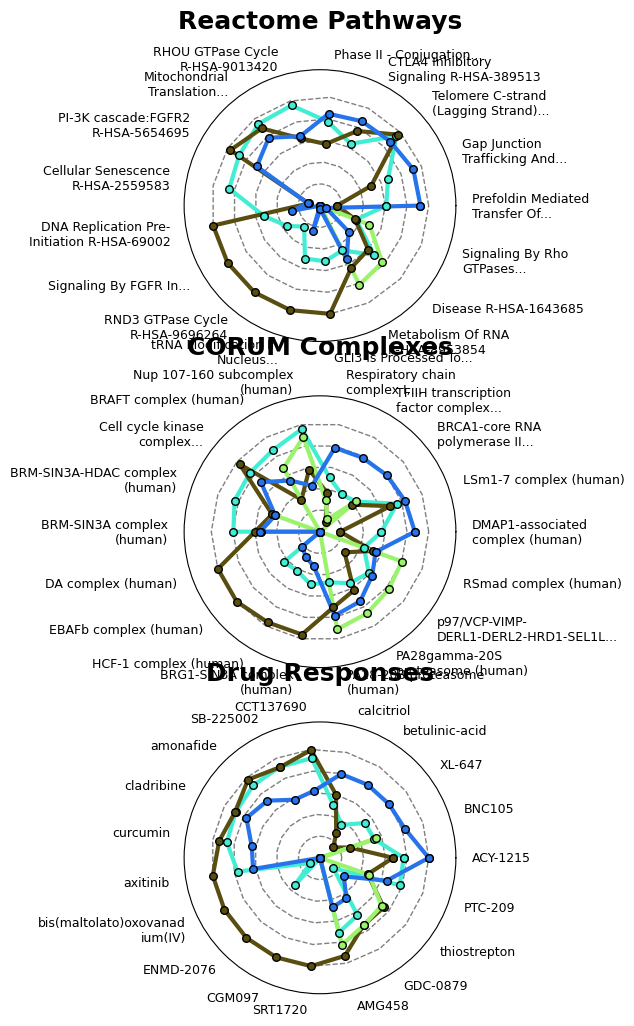

In [46]:
max_processes = 3
# --- Create one combined figure ---
fig, axes = plt.subplots(3, 1, figsize=(18, 12), subplot_kw=dict(polar=True))

for ax, (title, df) in zip(axes, dfs.items()):
    df = df[df["ModelID"].isin(model_ids)].copy()

    # Apply process limit if set
    cols = feature_colnames[title]
    # if max_processes is not None:
    #     cols = cols[:max_processes]

    make_radar(ax, df, cols, title, global_max, model_ids=model_ids)

In [ ]:
# Shared legend (one for all)
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(0.5, -0.05),
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("visualize/combined_radar_plots.png", dpi=600,
#             bbox_inches="tight", transparent=True)
plt.show()

## testing

In [5]:
model_colors = generate_random_palette(len(model_ids), seed=12)
model_colors

[(0.25660503201582907, 0.9323619711728774, 0.8292577291672704),
 (0.3484708479375381, 0.3074749658243011, 0.0645616837705435),
 (0.6096646070080306, 0.9514553535026719, 0.4209623091794289)]

TypeError: list indices must be integers or slices, not str

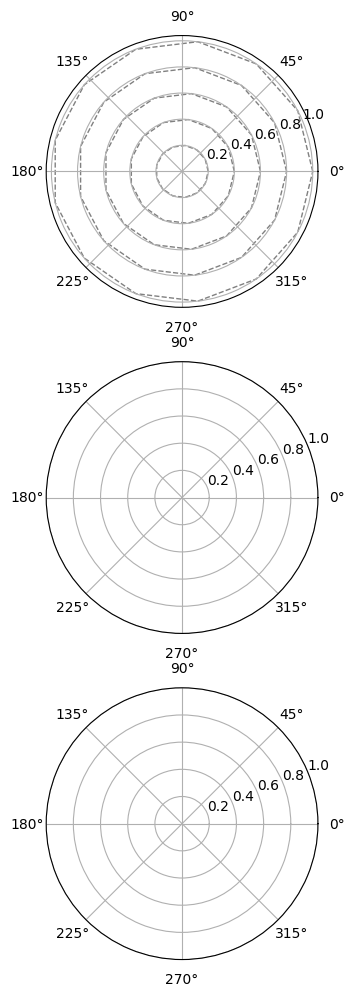

In [4]:
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from app_utils import (
    clean_label,
    generate_random_palette,
    make_radar,
    place_labels_polar,
    truncate_label,
)

model_ids = ["ACH-000323", "ACH-002083", "ACH-002228"]
files = {
    "Reactome Pathways": "../5.drug-dependency/results/all_reactome_results.parquet",
    "CORUM Complexes": "../5.drug-dependency/results/all_corum_results.parquet",
    "Drug Responses": "../5.drug-dependency/results/all_drug_results.parquet",
}
# Adjust these if your column names differ
feature_colnames = {
    "Reactome Pathways": "reactome_pathway",
    "CORUM Complexes": "reactome_pathway",
    "Drug Responses": "name",
}
score_col = "pathway_score"

model_colors = {
    "ACH-000323": "#00FFFF",  # cyan
    "ACH-002083": "#FF69B4",  # pink
    "ACH-002228": "#800080",  # purple
}

global_max = 0
dfs = {}
for name, file in files.items():
    df = pd.read_parquet(file)
    dfs[name] = df
    if df[score_col].max() > global_max:
        global_max = df[score_col].max()

# --- Create one combined figure ---
fig, axes = plt.subplots(3, 1, figsize=(18, 12), subplot_kw=dict(polar=True))

for ax, (title, df) in zip(axes, dfs.items()):
    df = df[df["ModelID"].isin(model_ids)].copy()
    make_radar(ax, df, feature_colnames[title], title, global_max)

# Shared legend (one for all)
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(0.5, -0.05),
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [10]:
import pandas as pd
from app_utils import latent_load_data

selected_diseases = [
    "Lung Adenocarcinoma",
    "Lung Squamous Cell Carcinoma",
    "Small Cell Lung Carcinoma",
    "Colorectal Adenocarcinoma",
    "Pancreatic Adenocarcinoma",
    "Ovarian Serous Cystadenocarcinoma",
    "Glioblastoma Multiforme",
    "Skin Cutaneous Melanoma",
    "Uterine Corpus Endometrial Carcinoma",
    "Prostate Adenocarcinoma",
]
reactome_matrix, corum_matrix, drug_matrix = latent_load_data()
full_df = reactome_matrix[
    reactome_matrix["OncotreePrimaryDisease"].isin(selected_diseases)
]

# Build summary: one row per unique (OncotreeLineage, OncotreePrimaryDisease) pair
# adjust column names below to match whatever lineage/cancer-type column your data actually has
group_cols = ["OncotreePrimaryDisease", "ModelID"]  # ← rename if needed
summary = (
    reactome_matrix.groupby(group_cols, dropna=False)
    .agg(n_models=("ModelID", "nunique"))
    .reset_index()
    .sort_values(group_cols)
    .rename(
        columns={
            "OncotreeLineage": "Lineage / Cancer Type",
            "OncotreePrimaryDisease": "Primary Disease",
            "n_models": "Cell Lines",
        }
    )
    .drop(columns=["Cell Lines"])
    .drop_duplicates()
)
summary

,Primary Disease,ModelID
0,Acute Myeloid Leukemia,ACH-000004
1,Acute Myeloid Leukemia,ACH-000005
2,Acute Myeloid Leukemia,ACH-000045
3,Acute Myeloid Leukemia,ACH-000113
4,Acute Myeloid Leukemia,ACH-000146
...,...,...
1145,Uterine Sarcoma/Mesenchymal,ACH-000939
1146,Uterine Sarcoma/Mesenchymal,ACH-001655
1147,Well-Differentiated Thyroid Cancer,ACH-000716
1148,Well-Differentiated Thyroid Cancer,ACH-000903
